**This notebook present llm prediction vs. baseline results.**

In [1]:
import json
import re
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
from scipy import stats

DEEP_TEAL     = "#2D4F54"
ROYAL_PURPLE  = "#7B539E"
SOFT_LAVENDER = "#B8A0D2"
FOREST_GREEN  = "#5A9448"
MUTED_PLUM    = "#9E4A78"
DARK_SLATE    = "#3A3D4A"

AIME_PALETTE = [
    DEEP_TEAL, ROYAL_PURPLE, SOFT_LAVENDER,
    FOREST_GREEN, MUTED_PLUM, DARK_SLATE,
]

AIME_RCPARAMS = {
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset":  "stix",
    "font.size":         18,
    "axes.facecolor":    "white",
    "axes.edgecolor":    DARK_SLATE,
    "axes.linewidth":    1.2,
    "axes.labelcolor":   DARK_SLATE,
    "axes.labelsize":    18,
    "axes.titlesize":    18,
    "axes.spines.top":   True,
    "axes.spines.right": True,
    "axes.prop_cycle":   plt.cycler("color", AIME_PALETTE),
    "axes.grid":         False,
    "xtick.color":         DARK_SLATE,
    "ytick.color":         DARK_SLATE,
    "xtick.labelsize":     16,
    "ytick.labelsize":     16,
    "xtick.major.width":   1.0,
    "ytick.major.width":   1.0,
    "xtick.major.size":    4.5,
    "ytick.major.size":    4.5,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
    "xtick.direction":     "out",
    "ytick.direction":     "out",
    "legend.frameon":    False,
    "legend.fontsize":   16,
    "legend.labelcolor": DARK_SLATE,
    "figure.facecolor":  "white",
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "savefig.pad_inches": 0.02,
    "savefig.facecolor": "white",
    "lines.linewidth":   1.8,
    "lines.markersize":  6.5,
}
plt.rcParams.update(AIME_RCPARAMS)

COL_MG  = ROYAL_PURPLE
COL_PT  = MUTED_PLUM

MG_PATH = "/Users/yaochenr/project/molecular_glue_extractor/output/results/260502_llm_baseline_eva_glue/llm_vs_baseline_results.json"
PT_PATH = "/Users/yaochenr/project/molecular_glue_extractor/output/results/260502_llm_baseline_eva_protacs/llm_vs_baseline_results.json"

with open(MG_PATH) as f:
    mg_results = json.load(f)
with open(PT_PATH) as f:
    pt_results = json.load(f)

def parse_numeric(val):
    if val is None:
        return np.nan
    s = str(val).strip()
    if not s:
        return np.nan
    s = re.sub(r'^[≈><=]+\s*', '', s)
    try:
        return float(s)
    except ValueError:
        return np.nan

def is_missing_value(val):
    if val is None:
        return True
    s = str(val).strip()
    return s == "" or s.lower() == "nan" or s.lower() == "none"

print("MG  total LLM:", mg_results["total_llm_records"], "  total baseline:", mg_results["total_baseline_records"])
print("PT  total LLM:", pt_results["total_llm_records"], "  total baseline:", pt_results["total_baseline_records"])


MG  total LLM: 246   total baseline: 136
PT  total LLM: 714   total baseline: 372


In [2]:
FIELDS = ["Assay", "Cell_Line", "DC50", "Dmax", "DC50_units", "DC50_h", "Dmax_h", "Dmax_conc"]


def extract(results):
    """Extract matched DC50/Dmax pairs, field counts, and topology stats from a results JSON."""
    gc = results["global_counts"]
    topo = {
        "l1": gc["intersection_l1"],
        "l2": gc["intersection_l2"],
        "l3": gc["intersection_l3"],
        "llm_only": gc["llm_only"],
        "bl_only": gc["baseline_only"],
        "total_llm": results["total_llm_records"],
        "total_bl": results["total_baseline_records"],
    }

    dc50_bl, dc50_llm = [], []
    dmax_bl, dmax_llm = [], []
    all_baseline, all_llm = [], []

    for doi, info in results["per_doi"].items():
        recs = info.get("records", {})
        for level_key in ("intersection_l1", "intersection_l2", "intersection_l3"):
            for item in recs.get(level_key, []):
                b, l = item["baseline"], item["llm"]
                all_baseline.append(b)
                all_llm.append(l)

                bd = parse_numeric(b.get("DC50"))
                ld = parse_numeric(l.get("DC50"))
                if np.isfinite(bd) and np.isfinite(ld):
                    dc50_bl.append(bd)
                    dc50_llm.append(ld)

                bm = parse_numeric(b.get("Dmax"))
                lm = parse_numeric(l.get("Dmax"))
                if np.isfinite(bm) and np.isfinite(lm):
                    dmax_bl.append(bm)
                    dmax_llm.append(lm)

        for item in recs.get("baseline_only", []):
            all_baseline.append(item["baseline"])
        for item in recs.get("llm_only", []):
            all_llm.append(item["llm"])

    counts_bl = {f: sum(1 for r in all_baseline if not is_missing_value(r.get(f))) for f in FIELDS}
    counts_llm = {f: sum(1 for r in all_llm if not is_missing_value(r.get(f))) for f in FIELDS}

    return {
        "topo": topo,
        "dc50_bl": np.array(dc50_bl),
        "dc50_llm": np.array(dc50_llm),
        "dmax_bl": np.array(dmax_bl),
        "dmax_llm": np.array(dmax_llm),
        "counts_bl": counts_bl,
        "counts_llm": counts_llm,
    }


def gain_label(bl, llm):
    if bl > 0:
        return f"{(llm - bl) / bl * 100:+.0f}%"
    return "De novo"


mg = extract(mg_results)
pt = extract(pt_results)

print(f"MG  DC50 pairs: {len(mg['dc50_bl'])}, Dmax pairs: {len(mg['dmax_bl'])}")
print(f"PT  DC50 pairs: {len(pt['dc50_bl'])}, Dmax pairs: {len(pt['dmax_bl'])}")
print()
print(f"{'Field':<12} | {'MG-BL':>6} {'MG-LLM':>7} {'gain':>9} | {'PT-BL':>6} {'PT-LLM':>7} {'gain':>9}")
print("-" * 70)
for f in FIELDS:
    print(f"{f:<12} | {mg['counts_bl'][f]:>6} {mg['counts_llm'][f]:>7} "
          f"{gain_label(mg['counts_bl'][f], mg['counts_llm'][f]):>9} | "
          f"{pt['counts_bl'][f]:>6} {pt['counts_llm'][f]:>7} "
          f"{gain_label(pt['counts_bl'][f], pt['counts_llm'][f]):>9}")


MG  DC50 pairs: 52, Dmax pairs: 22
PT  DC50 pairs: 145, Dmax pairs: 152

Field        |  MG-BL  MG-LLM      gain |  PT-BL  PT-LLM      gain
----------------------------------------------------------------------
Assay        |     41     245     +498% |     10     711    +7010%
Cell_Line    |     39     239     +513% |    360     713      +98%
DC50         |    128     212      +66% |    299     502      +68%
Dmax         |     71     134      +89% |    257     515     +100%
DC50_units   |    128     212      +66% |    299     502      +68%
DC50_h       |      5     162    +3140% |    265     388      +46%
Dmax_h       |     30     101     +237% |    231     369      +60%
Dmax_conc    |     30      29       -3% |      0     186   De novo


In [3]:
VENN_LLM_FILL = SOFT_LAVENDER
VENN_LLM_EDGE = ROYAL_PURPLE
VENN_BL_FILL  = DARK_SLATE
VENN_BL_EDGE  = DARK_SLATE
VENN_L3       = FOREST_GREEN
VENN_L2       = FOREST_GREEN
VENN_L1       = DEEP_TEAL


def _estimate_lens_area(cx_llm, cx_bl, cy, a_llm, b_llm, a_bl, b_bl, n=400):
    left = max(cx_llm - a_llm, cx_bl - a_bl)
    right = min(cx_llm + a_llm, cx_bl + a_bl)
    top = min(cy + min(b_llm, b_bl), cy + b_bl)
    bot = max(cy - min(b_llm, b_bl), cy - b_bl)
    if left >= right or bot >= top:
        return 0.0
    xs = np.linspace(left, right, n)
    ys = np.linspace(bot, top, n)
    xx, yy = np.meshgrid(xs, ys)
    in_llm = ((xx - cx_llm) / a_llm) ** 2 + ((yy - cy) / b_llm) ** 2 <= 1.0
    in_bl = ((xx - cx_bl) / a_bl) ** 2 + ((yy - cy) / b_bl) ** 2 <= 1.0
    cell_area = (right - left) * (top - bot) / (n * n)
    return np.sum(in_llm & in_bl) * cell_area


def draw_venn(ax, topo):
    """Render a stratified Venn diagram into the given Axes — no titles."""
    l1, l2, l3 = topo["l1"], topo["l2"], topo["l3"]
    llm_only, bl_only = topo["llm_only"], topo["bl_only"]
    total_llm, total_bl = topo["total_llm"], topo["total_bl"]
    overlap = l1 + l2 + l3

    pct_bl_only = bl_only / total_bl * 100
    pct_llm_only = llm_only / total_bl * 100
    pct_l3 = overlap / total_bl * 100
    pct_l2 = (l1 + l2) / total_bl * 100
    pct_l1 = l1 / total_bl * 100
    pct_overlap = pct_l3

    aspect = 1.6
    b_bl = 0.22
    b_llm = b_bl * np.sqrt(total_llm / total_bl)
    a_bl = aspect * b_bl
    a_llm = aspect * b_llm

    baseline_ellipse_area = np.pi * a_bl * b_bl
    target_lens_area = (pct_overlap / 100.0) * baseline_ellipse_area

    cy = 0.50
    gap_lo, gap_hi = 0.01, a_llm + a_bl
    for _ in range(50):
        gap_mid = (gap_lo + gap_hi) / 2
        cx_llm_test = 0.5 - gap_mid / 2
        cx_bl_test = 0.5 + gap_mid / 2
        area = _estimate_lens_area(cx_llm_test, cx_bl_test, cy, a_llm, b_llm, a_bl, b_bl, n=400)
        if area > target_lens_area:
            gap_lo = gap_mid
        else:
            gap_hi = gap_mid
    gap = (gap_lo + gap_hi) / 2
    cx_llm = 0.5 - gap / 2
    cx_bl = 0.5 + gap / 2

    lens_left = cx_bl - a_bl
    lens_right = cx_llm + a_llm
    lens_cx = (lens_left + lens_right) / 2
    lens_cy = cy
    lens_b = min(b_llm, b_bl)

    x_min = cx_llm - a_llm - 0.005
    x_max = cx_bl + a_bl + 0.22
    y_min = cy - max(b_llm, b_bl) - 0.01
    y_max = cy + max(b_llm, b_bl) + 0.01

    ellipse_llm = Ellipse((cx_llm, cy), 2 * a_llm, 2 * b_llm,
                          facecolor=VENN_LLM_FILL, alpha=0.40, lw=1.5,
                          edgecolor=VENN_LLM_EDGE, zorder=1)
    ellipse_bl = Ellipse((cx_bl, cy), 2 * a_bl, 2 * b_bl,
                         facecolor=VENN_BL_FILL, alpha=0.18, lw=1.5,
                         edgecolor=VENN_BL_EDGE, zorder=1)
    ax.add_patch(ellipse_llm)
    ax.add_patch(ellipse_bl)

    clip_bl = Ellipse((cx_bl, cy), 2 * a_bl, 2 * b_bl,
                      transform=ax.transData, facecolor='none', edgecolor='none')
    ax.add_patch(clip_bl)
    l3_fill = Ellipse((cx_llm, cy), 2 * a_llm, 2 * b_llm,
                      facecolor=VENN_L3, edgecolor='none', alpha=0.55, zorder=2)
    ax.add_patch(l3_fill)
    l3_fill.set_clip_path(clip_bl)
    lens_half_width = (lens_right - lens_left) / 2
    nested_aspect = lens_half_width / lens_b if lens_b > 0 else 1.4
    r_max = lens_b * 0.75
    r_l2 = r_max * np.sqrt(pct_l2 / pct_l3) if pct_l3 > 0 else 0
    r_l1 = r_max * np.sqrt(pct_l1 / pct_l3) if pct_l3 > 0 else 0
    r_l1 = max(r_l1, 0.018)

    e_l2 = Ellipse((lens_cx, lens_cy), 2 * nested_aspect * r_l2, 2 * r_l2,
                   facecolor=VENN_L2, edgecolor="white", lw=1.2, alpha=0.92, zorder=3)
    ax.add_patch(e_l2)
    e_l1 = Ellipse((lens_cx, lens_cy), 2 * nested_aspect * r_l1, 2 * r_l1,
                   facecolor=VENN_L1, edgecolor="white", lw=1.2, alpha=1.0, zorder=4)
    ax.add_patch(e_l1)

    ax.text(cx_llm - a_llm * 0.45, cy, f"LLM Only\n{pct_llm_only:.1f}%",
            fontsize=17, fontweight="bold", ha="center", va="center",
            color=ROYAL_PURPLE, zorder=5)

    bl_target_x = cx_bl + a_bl * 0.65
    bl_target_y = cy
    bl_label_x = cx_bl + a_bl + 0.02
    bl_label_y = cy - 0.02
    ax.annotate(f"BL Only\n{pct_bl_only:.1f}%",
                xy=(bl_target_x, bl_target_y),
                xytext=(bl_label_x, bl_label_y),
                fontsize=16, fontweight="bold", color=DARK_SLATE,
                ha="left", va="center", zorder=5,
                arrowprops=dict(arrowstyle="-|>", color=DARK_SLATE, lw=1.0,
                                connectionstyle="arc3,rad=0.0"))

    l3_label_y = lens_cy + (r_l2 + lens_b) / 2 * 0.85
    ax.text(lens_cx, l3_label_y, f"L3: {pct_l3:.1f}%", fontsize=16, fontweight="bold",
            ha="center", va="center", color=DEEP_TEAL, zorder=5)

    l2_label_y = lens_cy + r_l2 * 0.45
    ax.text(lens_cx, l2_label_y, f"L2: {pct_l2:.1f}%", fontsize=16, fontweight="bold",
            ha="center", va="center", color="white", zorder=5)

    l1_label_x = lens_cx + nested_aspect * r_l1 + 0.12
    l1_label_y = lens_cy - 0.08
    ax.annotate(f"L1: {pct_l1:.1f}%", xy=(lens_cx, lens_cy),
                xytext=(l1_label_x, l1_label_y),
                fontsize=16, fontweight="bold", color=DEEP_TEAL, zorder=5,
                arrowprops=dict(arrowstyle="-|>", color=DEEP_TEAL, lw=1.2,
                                connectionstyle="arc3,rad=-0.2"))

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal")
    ax.axis("off")


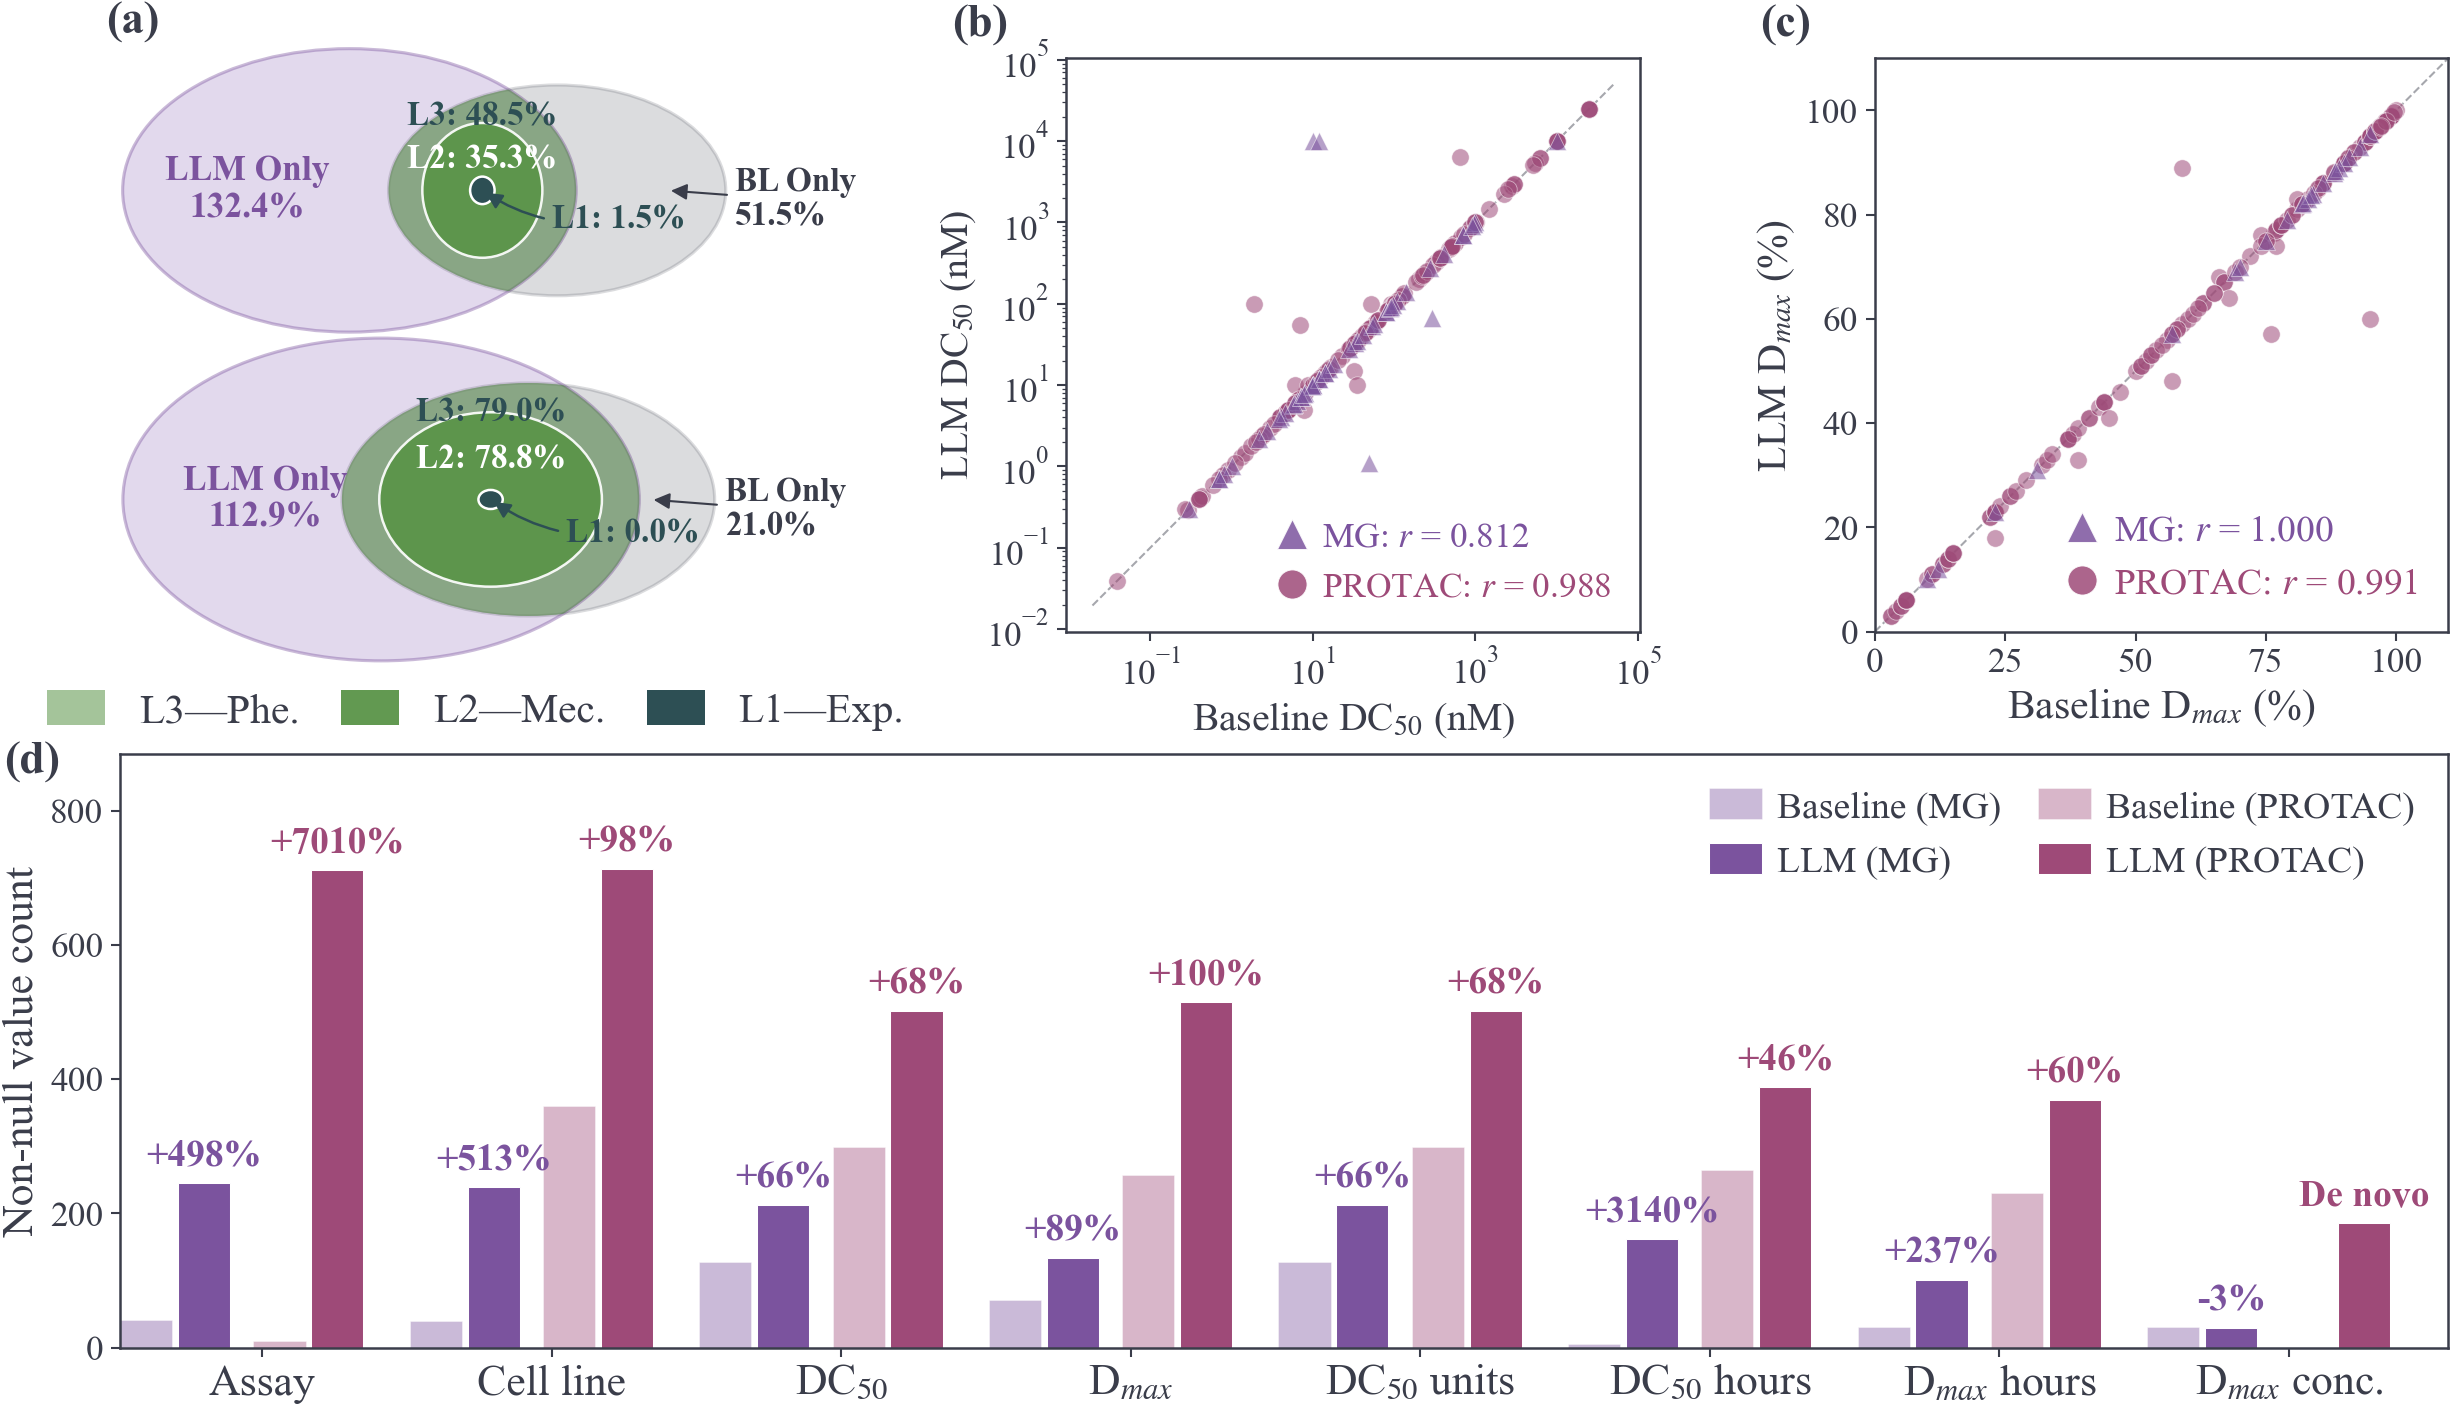

In [4]:
fig = plt.figure(figsize=(16, 9.5))
gs = gridspec.GridSpec(2, 3, height_ratios=[1.0, 0.92],
                       width_ratios=[1.24, 1.0, 1.0],
                       hspace=0.14, wspace=0.38,
                       left=0.02, right=0.99, top=0.99, bottom=0.06)

gsA = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[0, 0], hspace=-0.08)
axA1 = fig.add_subplot(gsA[0, 0])
axA2 = fig.add_subplot(gsA[1, 0])
draw_venn(axA1, mg["topo"])
draw_venn(axA2, pt["topo"])

venn_handles = [
    mpatches.Patch(facecolor=FOREST_GREEN, alpha=0.55, label="L3—Phe."),
    mpatches.Patch(facecolor=FOREST_GREEN, alpha=0.95, label="L2—Mec."),
    mpatches.Patch(facecolor=DEEP_TEAL,                 label="L1—Exp."),
]
axA2.legend(handles=venn_handles, loc="upper center",
            bbox_to_anchor=(0.5, 0.04), ncol=3, fontsize=20,
            handlelength=1.4, handleheight=0.9, columnspacing=1.0,
            labelcolor=DARK_SLATE)

axB = fig.add_subplot(gs[0, 1])
axB.scatter(pt["dc50_bl"], pt["dc50_llm"], color=COL_PT, marker="o",
            s=70, alpha=0.55, edgecolors="white", linewidths=0.4, zorder=2)
axB.scatter(mg["dc50_bl"], mg["dc50_llm"], color=COL_MG, marker="^",
            s=75, alpha=0.55, edgecolors="white", linewidths=0.4, zorder=3)

dc50_all_bl = np.concatenate([mg["dc50_bl"], pt["dc50_bl"]])
dc50_all_llm = np.concatenate([mg["dc50_llm"], pt["dc50_llm"]])
lo = min(dc50_all_bl.min(), dc50_all_llm.min()) * 0.5
hi = max(dc50_all_bl.max(), dc50_all_llm.max()) * 2
axB.plot([lo, hi], [lo, hi], "--", color=DARK_SLATE, lw=1, alpha=0.45, zorder=1)
axB.set_xscale("log")
axB.set_yscale("log")
axB.set_xlabel("Baseline DC$_{50}$ (nM)", fontsize=19)
axB.set_ylabel("LLM DC$_{50}$ (nM)", fontsize=19)
axB.tick_params(axis="both", labelsize=17)
axB.set_aspect("equal")

r_mg, _ = stats.pearsonr(np.log10(mg["dc50_bl"]), np.log10(mg["dc50_llm"]))
r_pt, _ = stats.pearsonr(np.log10(pt["dc50_bl"]), np.log10(pt["dc50_llm"]))
b_handles = [
    Line2D([0], [0], marker="^", color="none",
           markerfacecolor=COL_MG, markeredgecolor="white", markeredgewidth=0.5,
           markersize=14, alpha=0.85, label=f"MG: $r$ = {r_mg:.3f}"),
    Line2D([0], [0], marker="o", color="none",
           markerfacecolor=COL_PT, markeredgecolor="white", markeredgewidth=0.5,
           markersize=14, alpha=0.85, label=f"PROTAC: $r$ = {r_pt:.3f}"),
]
axB.legend(handles=b_handles, loc="lower right", fontsize=17,
           handlelength=0.9, handletextpad=0.4, borderpad=0.3,
           labelcolor=[COL_MG, COL_PT])

axC = fig.add_subplot(gs[0, 2])
axC.scatter(pt["dmax_bl"], pt["dmax_llm"], color=COL_PT, marker="o",
            s=70, alpha=0.55, edgecolors="white", linewidths=0.4, zorder=2)
axC.scatter(mg["dmax_bl"], mg["dmax_llm"], color=COL_MG, marker="^",
            s=75, alpha=0.55, edgecolors="white", linewidths=0.4, zorder=3)
axC.plot([0, 110], [0, 110], "--", color=DARK_SLATE, lw=1, alpha=0.45, zorder=1)
axC.set_xlim(0, 110)
axC.set_ylim(0, 110)
axC.set_xlabel("Baseline D$_{max}$ (%)", fontsize=20)
axC.set_ylabel("LLM D$_{max}$ (%)", fontsize=20)
axC.tick_params(axis="both", labelsize=17)
axC.set_aspect("equal")

r_mg_d, _ = stats.pearsonr(mg["dmax_bl"], mg["dmax_llm"])
r_pt_d, _ = stats.pearsonr(pt["dmax_bl"], pt["dmax_llm"])
c_handles = [
    Line2D([0], [0], marker="^", color="none",
           markerfacecolor=COL_MG, markeredgecolor="white", markeredgewidth=0.5,
           markersize=14, alpha=0.85,
           label=f"MG: $r$ = {r_mg_d:.3f}"),
    Line2D([0], [0], marker="o", color="none",
           markerfacecolor=COL_PT, markeredgecolor="white", markeredgewidth=0.5,
           markersize=14, alpha=0.85,
           label=f"PROTAC: $r$ = {r_pt_d:.3f}"),
]
axC.legend(handles=c_handles, loc="lower right", fontsize=18,
           handlelength=0.9, handletextpad=0.4, borderpad=0.3,
           labelcolor=[COL_MG, COL_PT])
axD = fig.add_subplot(gs[1, :])
x = np.arange(len(FIELDS))
w = 0.18
offsets = [-0.40, -0.20, +0.06, +0.26]

vals_mg_bl  = [mg["counts_bl"][f] for f in FIELDS]
vals_mg_llm = [mg["counts_llm"][f] for f in FIELDS]
vals_pt_bl  = [pt["counts_bl"][f] for f in FIELDS]
vals_pt_llm = [pt["counts_llm"][f] for f in FIELDS]

bars_mg_bl  = axD.bar(x + offsets[0], vals_mg_bl,  w,
                      color=COL_MG, alpha=0.40,
                      edgecolor="white", linewidth=0.5, label="Baseline (MG)")
bars_mg_llm = axD.bar(x + offsets[1], vals_mg_llm, w,
                      color=COL_MG,
                      edgecolor="white", linewidth=0.5, label="LLM (MG)")
bars_pt_bl  = axD.bar(x + offsets[2], vals_pt_bl,  w,
                      color=COL_PT, alpha=0.40,
                      edgecolor="white", linewidth=0.5, label="Baseline (PROTAC)")
bars_pt_llm = axD.bar(x + offsets[3], vals_pt_llm, w,
                      color=COL_PT,
                      edgecolor="white", linewidth=0.5, label="LLM (PROTAC)")

y_offset = max(max(vals_mg_llm), max(vals_pt_llm)) * 0.020

def _place_gain(ax, bar, text, color):
    x_pos = bar.get_x() + bar.get_width() / 2
    ax.text(x_pos, bar.get_height() + y_offset, text,
            ha="center", va="bottom",
            fontsize=18, fontweight="bold", color=color)

for bar, bl, llm in zip(bars_mg_llm, vals_mg_bl, vals_mg_llm):
    _place_gain(axD, bar, gain_label(bl, llm), COL_MG)
for bar, bl, llm in zip(bars_pt_llm, vals_pt_bl, vals_pt_llm):
    _place_gain(axD, bar, gain_label(bl, llm), COL_PT)

field_labels = ["Assay", "Cell line",
                "DC$_{50}$", "D$_{max}$",
                "DC$_{50}$ units", "DC$_{50}$ hours",
                "D$_{max}$ hours",  "D$_{max}$ conc."]
axD.set_xticks(x)
axD.set_xticklabels(field_labels, fontsize=21)
axD.set_ylabel("Non-null value count", fontsize=21)
axD.tick_params(axis="y", labelsize=17)
axD.set_xlim(-0.49, len(FIELDS) - 0.45)

axD.legend(ncol=2, loc="upper right", fontsize=18,
           handlelength=1.4, handleheight=0.9, columnspacing=1.0,
           handletextpad=0.4)
axD.set_ylim(0, max(max(vals_mg_llm), max(vals_pt_llm)) * 1.24)

def add_panel_label(ax, label, x_off=-0.18, y_off=1.02):
    ax.text(x_off, y_off, label, transform=ax.transAxes,
            fontsize=22, fontweight="bold", va="bottom", ha="left",
            color=DARK_SLATE)

add_panel_label(axA1, "(a)", x_off=-0.02, y_off=1.00)
add_panel_label(axB,  "(b)", x_off=-0.20, y_off=1.02)
add_panel_label(axC,  "(c)", x_off=-0.20, y_off=1.02)
add_panel_label(axD,  "(d)", x_off=-0.05, y_off=0.95)
out_dir = "figures"
os.makedirs(out_dir, exist_ok=True)
fig.savefig(f"{out_dir}/llm_vs_baseline_combined.pdf")
fig.savefig(f"{out_dir}/llm_vs_baseline_combined.png")
plt.show()


# Glue data verification

## Baseline Only

In [7]:
import json
import pandas as pd

with open("/Users/yaochenr/project/molecular_glue_extractor/output/results/260502_llm_baseline_eva_glue/llm_vs_baseline_results.json") as f:
    results = json.load(f)

baseline_only_records = []
for doi, info in results["per_doi"].items():
    recs = info.get("records", {})
    for item in recs.get("baseline_only", []):
        baseline_only_records.append(item["baseline"])

df_bl_only = pd.DataFrame(baseline_only_records)
print(f"Baseline only records: {len(df_bl_only)}")
print(df_bl_only.head())

df_bl_only.to_csv("/Users/yaochenr/project/molecular_glue_extractor/output/results/260502_llm_baseline_eva_glue/26_05_02_baseline_only_records.csv", index=False)
print("\nSaved to /Users/yaochenr/project/molecular_glue_extractor/output/results/260502_llm_baseline_eva_glue/26_05_02_baseline_only_records.csv")

Baseline only records: 70
   Record_ID  Compound_ID Compound_Name  \
0         11           11           26b   
1         12           12     CCT368682   
2         12           12     CCT368682   
3         14           14     CCT369260   
4        464          425           24a   

                                              SMILES  \
0  C[C@@H]1C[C@H](C)CN(C2=NC=C(Cl)C(NC3=CC=C4C(=C...   
1  C[C@@H]1C[C@H](C)CN(C2=NC=C(Cl)C(NC3=CC=C4C(=C...   
2  C[C@@H]1C[C@H](C)CN(C2=NC=C(Cl)C(NC3=CC=C4C(=C...   
3  C[C@@H]1CN(C2=NC=C(Cl)C(NC3=CC=C4C(=C3)N(CCC(C...   
4  CC1CCCN(C2=NC=C(Cl)C(NC3=CC=C4C(=C3)N(CCC(C)(C...   

                                            StdInChl  \
0  InChI=1S/C25H34ClN5O2/c1-16-10-17(2)15-30(14-1...   
1  InChI=1S/C24H33ClN6O2/c1-15-10-16(2)14-30(13-1...   
2  InChI=1S/C24H33ClN6O2/c1-15-10-16(2)14-30(13-1...   
3  InChI=1S/C24H31ClF2N6O2/c1-14-12-32(13-15(2)24...   
4  InChI=1S/C23H31ClN6O2/c1-15-6-5-10-29(14-15)21...   

                   StdInChIKey Degradatio

## LLM Only

In [8]:
import json
import pandas as pd

with open("/Users/yaochenr/project/molecular_glue_extractor/output/results/260502_llm_baseline_eva_glue/llm_vs_baseline_results.json") as f:
    results = json.load(f)

llm_only_records = []
for doi, info in results["per_doi"].items():
    recs = info.get("records", {})
    for item in recs.get("llm_only", []):
        llm_only_records.append(item["llm"])

df_llm_only = pd.DataFrame(llm_only_records)
print(f"LLM only records: {len(df_llm_only)}")

# Randomly sample 100 data points
df_llm_only_sample = df_llm_only.sample(n=100, random_state=42)
print(f"Sampled records: {len(df_llm_only_sample)}")
print(df_llm_only_sample.head())

df_llm_only_sample.to_csv("/Users/yaochenr/project/molecular_glue_extractor/output/results/260502_llm_baseline_eva_glue/26_05_02_llm_only_records_sample100.csv", index=False)
print("\nSaved to /Users/yaochenr/project/molecular_glue_extractor/output/results/260502_llm_baseline_eva_glue/26_05_02_llm_only_records_sample100.csv")

LLM only records: 180
Sampled records: 100
                                DOI Compound_Name  \
19     10.1021/acs.jmedchem.1c02175            8b   
42   10.1021/acsmedchemlett.4c00250            16   
153      10.1038/s41589-023-01409-z           Z10   
78       10.1038/s41467-024-44698-1        SJ0040   
145      10.1038/s41589-023-01409-z          DS69   

                                            IUPAC_Name  \
19   (S)-10-((5-Chloro-2-((R)-4,4-difluoro-3-hydrox...   
42   N-(2-(2,6-dioxopiperidin-3-yl)-1-oxoisoindolin...   
153                                               None   
78   N-(2-(2,6-dioxopiperidin-3-yl)-1-oxoisoindolin...   
145  (R)-2-((9-isopropyl-6-((3-(6-methylpyridin-2-y...   

                                                SMILES SMILES_Source  \
19   ClC=1C(=NC(=NC1)N1C[C@H](C(CC1)(F)F)O)NC1=CC=2...         OPSIN   
42   O=C1NC(CCC1N1C(C2=CC=C(C=C2C1)NC(C1=CC(=CC=C1)...         OPSIN   
153                                               None          None   
7

# PROTAC data verfication

## Baseline Only

In [ ]:
import json
import pandas as pd

with open("/Users/yaochenr/project/molecular_glue_extractor/output/results/260502_llm_baseline_eva_protacs/llm_vs_baseline_results.json") as f:
    results = json.load(f)

baseline_only_records = []
for doi, info in results["per_doi"].items():
    recs = info.get("records", {})
    for item in recs.get("baseline_only", []):
        baseline_only_records.append(item["baseline"])

df_bl_only = pd.DataFrame(baseline_only_records)
print(f"Baseline only records: {len(df_bl_only)}")

df_bl_only_sample = df_bl_only.sample(n=20, random_state=42)
print(f"Sampled records: {len(df_bl_only_sample)}")
print(df_bl_only_sample.head())

df_bl_only_sample.to_csv("../output/results/260502_llm_baseline_eva_protacs/26_05_02_baseline_only_records_sample20.csv", index=False)
print("\nSaved to ../output/results/260502_llm_baseline_eva_protacs/26_05_02_baseline_only_records_sample20.csv")

Baseline only records: 78
Sampled records: 20
    Record_ID  Compound_ID Compound_Name  \
33       7027         3213          PPC5   
0        3558          714          None   
34       7029         3214          PPC6   
12       8194         4269          None   
10       8198         4270          None   

                                               SMILES  \
33  CC1=C(C2=CC=C([C@H](C)NC(=O)[C@@H]3C[C@@H](O)C...   
0   O=C1CCC(N2C(=O)C3=CC=CC(NCCOCCOCCOCCOCCNC(=O)C...   
34  CC1=C(C2=CC=C([C@H](C)NC(=O)[C@@H]3C[C@@H](O)C...   
12  CC1=C(C2=CC=C(CNC(=O)[C@@H]3C[C@H](O)CN3C(=O)[...   
10  O=C1CCC(N2CC3=C(NC(=O)COCCCCOC4=CC=C(C5CCN(C6=...   

                                                InChI  \
33  InChI=1S/C79H99ClF3N11O11S4/c1-53(55-15-17-57(...   
0   InChI=1S/C55H68ClN7O13S2/c56-43-14-10-40(11-15...   
34  InChI=1S/C80H101ClF3N11O11S4/c1-54(56-16-18-58...   
12  InChI=1S/C47H60F3N9O6S/c1-30-41(66-29-52-30)34...   
10  InChI=1S/C36H39F3N8O6/c37-36(38,39)35-43-42-29...   

   

## LLM only

In [ ]:
import json
import pandas as pd

with open("/Users/yaochenr/project/molecular_glue_extractor/output/results/260430_llm_baseline_eva_protacs/llm_vs_baseline_results.json") as f:
    results = json.load(f)

llm_only_records = []
for doi, info in results["per_doi"].items():
    recs = info.get("records", {})
    for item in recs.get("llm_only", []):
        llm_only_records.append(item["llm"])

df_llm_only = pd.DataFrame(llm_only_records)
print(f"LLM only records: {len(df_llm_only)}")

df_llm_only_sample = df_llm_only.sample(n=40, random_state=42)
print(f"Sampled records: {len(df_llm_only_sample)}")
print(df_llm_only_sample.head())

df_llm_only_sample.to_csv("../output/results/260430_llm_baseline_eva_protacs/26_04_30_llm_only_records_sample40.csv", index=False)
print("\nSaved to ../output/results/260430_llm_baseline_eva_protacs/26_04_30_llm_only_records_sample40.csv")